In [ ]:
import pandas as pd

## Preprocessing Tiktok

In [ ]:
df_tiktok = pd.read_csv('social media influencers - Tiktok sep 2022.csv')

In [ ]:
df_tiktok

,S.no,Tiktoker name,Tiktok name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
0,1,jypestraykids,Stray Kids,13.8M,6.4M,2.3M,50.2K,34.2K
1,2,khaby.lame,Khabane lame,149.2M,17.3M,2.3M,15.2K,8.7K
2,3,scarlettsspam2,scarlett,2.1M,17.9M,845.8K,53.9K,6.3K
3,4,addisonre,Addison Rae,88.7M,22M,906.6K,7.6K,26.2K
4,5,belindatok,Belinda,4.8M,14.2M,1.5M,14.5K,15.3K
...,...,...,...,...,...,...,...,...
995,996,brendadialoy,Brenda Dialoy,371.9K,1.2M,187.5K,626,2K
996,997,jujufitcats,Juju Fitcats,4.3M,2.2M,280.8K,380,558
997,998,xoteam,XO Team,37.8M,2.5M,180.2K,859,450
998,999,kimsnwuo,️️,100.9K,957.4K,226.8K,908,1.7K


In [ ]:
df_tiktok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   S.no           1000 non-null   int64 
 1   Tiktoker name  1000 non-null   object
 2   Tiktok name    999 non-null    object
 3   Subscribers    1000 non-null   object
 4   Views avg.     1000 non-null   object
 5   Likes avg.     1000 non-null   object
 6   Comments avg.  1000 non-null   object
 7   Shares avg.    1000 non-null   object
dtypes: int64(1), object(7)
memory usage: 62.6+ KB


In [ ]:
# Check for nulls
print(f"Number of nulls: {df_tiktok.isnull().sum()}")

Number of nulls: S.no             0
Tiktoker name    0
Tiktok name      1
Subscribers      0
Views avg.       0
Likes avg.       0
Comments avg.    0
Shares avg.      0
dtype: int64


In [ ]:
df_tiktok[df_tiktok.isna().any(axis=1)]

,S.no,Tiktoker name,Tiktok name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
530,531,iloveyourmomscatt,NaN,8.2K,1.3M,159.3K,4.9K,3.3K


In [ ]:
# En caso de que quisieramos tomar acción par borrar sería df.dropna()

In [ ]:
# Check for duplicates
duplicate_index = ["Tiktoker name"]
print(f"Number of duplicates: {df_tiktok.duplicated(duplicate_index).sum()}")
df_tiktok[df_tiktok.duplicated(duplicate_index, keep=False)].sort_values(duplicate_index)

Number of duplicates: 4


,S.no,Tiktoker name,Tiktok name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
149,150,andyarthursmith,Andy Arthur Smith,2.2M,3.3M,564.7K,3.3K,2.8K
151,152,andyarthursmith,Andy Arthur Smith,2.2M,3.3M,564.7K,3.3K,2.8K
136,137,brookemonk_,Brooke Monk,23.6M,5.9M,678.9K,1.9K,1.4K
154,155,brookemonk_,Brooke Monk,23.6M,5.7M,620.8K,1.8K,1.3K
39,40,lexibrookerivera,Lexi Rivera,23.2M,7.5M,992.5K,8.5K,1.8K
66,67,lexibrookerivera,Lexi Rivera,23.4M,7.6M,870.6K,3.1K,1.8K
148,149,loganpaul,Logan Paul,15.9M,4.8M,976.9K,1.4K,1K
150,151,loganpaul,Logan Paul,15.9M,4.8M,976.9K,1.4K,1K


In [ ]:
# Fix duplicates
df_tiktok = df_tiktok.drop_duplicates(subset=duplicate_index, keep="first")
df_tiktok

,S.no,Tiktoker name,Tiktok name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
0,1,jypestraykids,Stray Kids,13.8M,6.4M,2.3M,50.2K,34.2K
1,2,khaby.lame,Khabane lame,149.2M,17.3M,2.3M,15.2K,8.7K
2,3,scarlettsspam2,scarlett,2.1M,17.9M,845.8K,53.9K,6.3K
3,4,addisonre,Addison Rae,88.7M,22M,906.6K,7.6K,26.2K
4,5,belindatok,Belinda,4.8M,14.2M,1.5M,14.5K,15.3K
...,...,...,...,...,...,...,...,...
995,996,brendadialoy,Brenda Dialoy,371.9K,1.2M,187.5K,626,2K
996,997,jujufitcats,Juju Fitcats,4.3M,2.2M,280.8K,380,558
997,998,xoteam,XO Team,37.8M,2.5M,180.2K,859,450
998,999,kimsnwuo,️️,100.9K,957.4K,226.8K,908,1.7K


In [ ]:
def convert_string_number_to_float(string_number):
  if 'K' in string_number:
    return float(string_number.replace('K', '')) * 1000
  if 'M' in string_number:
    return float(string_number.replace('M', '')) * 1000000
  return float(string_number)

In [ ]:
df_tiktok["Subscribers"] = df_tiktok["Subscribers"].apply(convert_string_number_to_float).copy()
df_tiktok["Views avg."] = df_tiktok["Views avg."].apply(convert_string_number_to_float).copy()
df_tiktok["Likes avg."] = df_tiktok["Likes avg."].apply(convert_string_number_to_float).copy()
df_tiktok["Comments avg."] = df_tiktok["Comments avg."].apply(convert_string_number_to_float).copy()
df_tiktok["Shares avg."] = df_tiktok["Shares avg."].apply(convert_string_number_to_float).copy()

/tmp/ipykernel_728/2032071746.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tiktok["Subscribers"] = df_tiktok["Subscribers"].apply(convert_string_number_to_float).copy()
/tmp/ipykernel_728/2032071746.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tiktok["Views avg."] = df_tiktok["Views avg."].apply(convert_string_number_to_float).copy()
/tmp/ipykernel_728/2032071746.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

In [ ]:
df_tiktok

,S.no,Tiktoker name,Tiktok name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
0,1,jypestraykids,Stray Kids,13800000.0,6400000.0,2300000.0,50200.0,34200.0
1,2,khaby.lame,Khabane lame,149200000.0,17300000.0,2300000.0,15200.0,8700.0
2,3,scarlettsspam2,scarlett,2100000.0,17900000.0,845800.0,53900.0,6300.0
3,4,addisonre,Addison Rae,88700000.0,22000000.0,906600.0,7600.0,26200.0
4,5,belindatok,Belinda,4800000.0,14200000.0,1500000.0,14500.0,15300.0
...,...,...,...,...,...,...,...,...
995,996,brendadialoy,Brenda Dialoy,371900.0,1200000.0,187500.0,626.0,2000.0
996,997,jujufitcats,Juju Fitcats,4300000.0,2200000.0,280800.0,380.0,558.0
997,998,xoteam,XO Team,37800000.0,2500000.0,180200.0,859.0,450.0
998,999,kimsnwuo,️️,100900.0,957400.0,226800.0,908.0,1700.0


In [ ]:
column_names = {
    "Tiktoker name": "Creator",
    "Tiktok name": "Channel Name",
}
df_tiktok = df_tiktok.rename(columns=column_names).copy()
df_tiktok

,S.no,Creator,Channel Name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
0,1,jypestraykids,Stray Kids,13800000.0,6400000.0,2300000.0,50200.0,34200.0
1,2,khaby.lame,Khabane lame,149200000.0,17300000.0,2300000.0,15200.0,8700.0
2,3,scarlettsspam2,scarlett,2100000.0,17900000.0,845800.0,53900.0,6300.0
3,4,addisonre,Addison Rae,88700000.0,22000000.0,906600.0,7600.0,26200.0
4,5,belindatok,Belinda,4800000.0,14200000.0,1500000.0,14500.0,15300.0
...,...,...,...,...,...,...,...,...
995,996,brendadialoy,Brenda Dialoy,371900.0,1200000.0,187500.0,626.0,2000.0
996,997,jujufitcats,Juju Fitcats,4300000.0,2200000.0,280800.0,380.0,558.0
997,998,xoteam,XO Team,37800000.0,2500000.0,180200.0,859.0,450.0
998,999,kimsnwuo,️️,100900.0,957400.0,226800.0,908.0,1700.0


In [ ]:
df_tiktok = df_tiktok.drop("S.no", axis=1)
df_tiktok

,Creator,Channel Name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
0,jypestraykids,Stray Kids,13800000.0,6400000.0,2300000.0,50200.0,34200.0
1,khaby.lame,Khabane lame,149200000.0,17300000.0,2300000.0,15200.0,8700.0
2,scarlettsspam2,scarlett,2100000.0,17900000.0,845800.0,53900.0,6300.0
3,addisonre,Addison Rae,88700000.0,22000000.0,906600.0,7600.0,26200.0
4,belindatok,Belinda,4800000.0,14200000.0,1500000.0,14500.0,15300.0
...,...,...,...,...,...,...,...
995,brendadialoy,Brenda Dialoy,371900.0,1200000.0,187500.0,626.0,2000.0
996,jujufitcats,Juju Fitcats,4300000.0,2200000.0,280800.0,380.0,558.0
997,xoteam,XO Team,37800000.0,2500000.0,180200.0,859.0,450.0
998,kimsnwuo,️️,100900.0,957400.0,226800.0,908.0,1700.0


In [ ]:
df_tiktok["Country"] = pd.NA
df_tiktok["Category"] = pd.NA
df_tiktok["Platform"] = "Tik Tok"
df_tiktok["Date"] = "Sep 2022"
df_tiktok

,Creator,Channel Name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.,Country,Category,Platform,Date
0,jypestraykids,Stray Kids,13800000.0,6400000.0,2300000.0,50200.0,34200.0,<NA>,<NA>,Tik Tok,Sep 2022
1,khaby.lame,Khabane lame,149200000.0,17300000.0,2300000.0,15200.0,8700.0,<NA>,<NA>,Tik Tok,Sep 2022
2,scarlettsspam2,scarlett,2100000.0,17900000.0,845800.0,53900.0,6300.0,<NA>,<NA>,Tik Tok,Sep 2022
3,addisonre,Addison Rae,88700000.0,22000000.0,906600.0,7600.0,26200.0,<NA>,<NA>,Tik Tok,Sep 2022
4,belindatok,Belinda,4800000.0,14200000.0,1500000.0,14500.0,15300.0,<NA>,<NA>,Tik Tok,Sep 2022
...,...,...,...,...,...,...,...,...,...,...,...
995,brendadialoy,Brenda Dialoy,371900.0,1200000.0,187500.0,626.0,2000.0,<NA>,<NA>,Tik Tok,Sep 2022
996,jujufitcats,Juju Fitcats,4300000.0,2200000.0,280800.0,380.0,558.0,<NA>,<NA>,Tik Tok,Sep 2022
997,xoteam,XO Team,37800000.0,2500000.0,180200.0,859.0,450.0,<NA>,<NA>,Tik Tok,Sep 2022
998,kimsnwuo,️️,100900.0,957400.0,226800.0,908.0,1700.0,<NA>,<NA>,Tik Tok,Sep 2022


In [ ]:
df_tiktok[df_tiktok.duplicated(["Channel Name"], keep=False)].sort_values("Channel Name")

,Creator,Channel Name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.,Country,Category,Platform,Date
34,iamferv,Fernanda,31500000.0,6600000.0,962300.0,10000.0,3900.0,<NA>,<NA>,Tik Tok,Sep 2022
167,ferchugimenez,Fernanda,7700000.0,4500000.0,825600.0,1500.0,1100.0,<NA>,<NA>,Tik Tok,Sep 2022
75,max7424453118,Max Taylor,2800000.0,3500000.0,572600.0,5200.0,9500.0,<NA>,<NA>,Tik Tok,Sep 2022
894,maxtaylorlifts,Max Taylor,8900000.0,1300000.0,231200.0,1200.0,1200.0,<NA>,<NA>,Tik Tok,Sep 2022
511,tommyunold,Tommy,11300000.0,2300000.0,317800.0,2200.0,172.0,<NA>,<NA>,Tik Tok,Sep 2022
606,tsezy,Tommy,4800000.0,2000000.0,253500.0,1900.0,735.0,<NA>,<NA>,Tik Tok,Sep 2022


## Preprocessing Youtube

In [ ]:
df_youtube = pd.read_csv('social media influencers - Youtube sep-2022.csv')

In [ ]:
df_youtube

,S.no,Name,Youtuber,Country,Subscribers,Category_2,Avg. views\r\n,Avg. likes,Avg Comments,Category_3
0,1,T-Series,tseries,India,224.4M,Music & Dance,141.5K,4.6K,125,NaN
1,2,Cocomelon - Nursery Rhymes,checkgate,NaN,142.5M,Education,12.5M,64.8K,0,NaN
2,3,PewDiePie,PewDiePie,United States,111.6M,Animation,1.9M,130.5K,7.4K,NaN
3,4,MrBeast,MrBeast6000,United States,104.1M,Video games,44.8M,2.2M,70.9K,Humor
4,5,✿ Kids Diana Show,✿ Kids Diana Show,NaN,100.5M,Animation,6.9M,34.8K,0,Toys
...,...,...,...,...,...,...,...,...,...,...
1042,996,Raditya Dika,Raditya Dika,Indonesia,9.9M,Food & Drinks,430.5K,14.8K,741,NaN
1043,997,Ini Talk Show,IniTalkShow,Indonesia,9.9M,Music & Dance,25.2K,290,17,Humor
1044,998,SpriteDer SPD,SpriteDer SPD,Thailand,9.9M,Humor,4.4M,154.4K,3.6K,NaN
1045,999,Classic Mr Bean,Classic Mr Bean,India,9.9M,NaN,132.6K,1.1K,53,NaN


In [ ]:
df_youtube.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1047 entries, 0 to 1046
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   S.no          1047 non-null   int64 
 1   Name          1047 non-null   object
 2   Youtuber      1047 non-null   object
 3   Country       868 non-null    object
 4    Subscribers  1047 non-null   object
 5   Category_2    746 non-null    object
 6   Avg. views
  1047 non-null   object
 7   Avg. likes    1047 non-null   object
 8   Avg Comments  1047 non-null   object
 9   Category_3    280 non-null    object
dtypes: int64(1), object(9)
memory usage: 81.9+ KB


In [ ]:
# Check for nulls
print(f"Number of nulls: {df_youtube.isnull().sum()}")

Number of nulls: S.no                0
Name                0
Youtuber            0
Country           179
 Subscribers        0
Category_2        301
Avg. views\r\n      0
Avg. likes          0
Avg Comments        0
Category_3        767
dtype: int64


In [ ]:
df_youtube[df_youtube.isna().any(axis=1)]

,S.no,Name,Youtuber,Country,Subscribers,Category_2,Avg. views\r\n,Avg. likes,Avg Comments,Category_3
0,1,T-Series,tseries,India,224.4M,Music & Dance,141.5K,4.6K,125,NaN
1,2,Cocomelon - Nursery Rhymes,checkgate,NaN,142.5M,Education,12.5M,64.8K,0,NaN
2,3,PewDiePie,PewDiePie,United States,111.6M,Animation,1.9M,130.5K,7.4K,NaN
4,5,✿ Kids Diana Show,✿ Kids Diana Show,NaN,100.5M,Animation,6.9M,34.8K,0,Toys
5,6,Like Nastya,Like Nastya,NaN,100.4M,Toys,5.3M,28.1K,0,NaN
...,...,...,...,...,...,...,...,...,...,...
1041,995,Fox News,FoxNewsChannel,United States,9.9M,News & Politics,148.9K,5.5K,1.6K,NaN
1042,996,Raditya Dika,Raditya Dika,Indonesia,9.9M,Food & Drinks,430.5K,14.8K,741,NaN
1044,998,SpriteDer SPD,SpriteDer SPD,Thailand,9.9M,Humor,4.4M,154.4K,3.6K,NaN
1045,999,Classic Mr Bean,Classic Mr Bean,India,9.9M,NaN,132.6K,1.1K,53,NaN


In [ ]:
# Check for duplicates
duplicate_index = ["Name"]
print(f"Number of duplicates: {df_youtube.duplicated(duplicate_index).sum()}")
df_youtube[df_youtube.duplicated(duplicate_index, keep=False)].sort_values(duplicate_index)

Number of duplicates: 48


,S.no,Name,Youtuber,Country,Subscribers,Category_2,Avg. views\r\n,Avg. likes,Avg Comments,Category_3
1023,976,123 GO! Hindi,123 GO! Hindi,India,10M,NaN,737.7K,5.7K,48,NaN
975,976,123 GO! Hindi,123 GO! Hindi,India,10M,NaN,737.7K,5.7K,48,NaN
1020,972,BERTH-OH,BERTH-OH,Mexico,10M,Autos & Vehicles,770.9K,24.2K,442,NaN
971,972,BERTH-OH,BERTH-OH,Mexico,10M,Autos & Vehicles,770.9K,24.2K,442,NaN
1009,960,Beast Philanthropy,Beast Philanthropy,United States,10.1M,Food & Drinks,7.9M,504.7K,23.6K,NaN
...,...,...,...,...,...,...,...,...,...,...
956,957,вДудь,вДудь,Russia,10.2M,News & Politics,0,0,0,NaN
978,979,مصطفى GAME OVER,مصطفى GAME OVER,Iraq,10M,NaN,625.8K,73.9K,3.2K,NaN
1026,979,مصطفى GAME OVER,مصطفى GAME OVER,Iraq,10M,NaN,625.8K,73.9K,3.2K,NaN
951,952,서은일상이야기,서은일상이야기,NaN,10.2M,NaN,19.7K,148,0,NaN


In [ ]:
# Checking for duplicates
df_youtube[df_youtube['Name'] == 'SpriteDer SPD']

,S.no,Name,Youtuber,Country,Subscribers,Category_2,Avg. views\r\n,Avg. likes,Avg Comments,Category_3
997,998,SpriteDer SPD,SpriteDer SPD,Thailand,9.9M,Humor,4.4M,154.4K,3.6K,NaN
1044,998,SpriteDer SPD,SpriteDer SPD,Thailand,9.9M,Humor,4.4M,154.4K,3.6K,NaN


In [ ]:
# Fix duplicates
df_youtube = df_youtube.drop_duplicates(subset=duplicate_index, keep="first")
df_youtube

,S.no,Name,Youtuber,Country,Subscribers,Category_2,Avg. views\r\n,Avg. likes,Avg Comments,Category_3
0,1,T-Series,tseries,India,224.4M,Music & Dance,141.5K,4.6K,125,NaN
1,2,Cocomelon - Nursery Rhymes,checkgate,NaN,142.5M,Education,12.5M,64.8K,0,NaN
2,3,PewDiePie,PewDiePie,United States,111.6M,Animation,1.9M,130.5K,7.4K,NaN
3,4,MrBeast,MrBeast6000,United States,104.1M,Video games,44.8M,2.2M,70.9K,Humor
4,5,✿ Kids Diana Show,✿ Kids Diana Show,NaN,100.5M,Animation,6.9M,34.8K,0,Toys
...,...,...,...,...,...,...,...,...,...,...
995,996,Raditya Dika,Raditya Dika,Indonesia,9.9M,Food & Drinks,430.5K,14.8K,741,NaN
996,997,Ini Talk Show,IniTalkShow,Indonesia,9.9M,Music & Dance,25.2K,290,17,Humor
997,998,SpriteDer SPD,SpriteDer SPD,Thailand,9.9M,Humor,4.4M,154.4K,3.6K,NaN
998,999,Classic Mr Bean,Classic Mr Bean,India,9.9M,NaN,132.6K,1.1K,53,NaN


In [ ]:
# Chequeando si tiene sentido la data de entrada raw
df_youtube[" Subscribers"].value_counts()

,count
Subscribers,
11.4M,28
10.6M,26
10.2M,23
10.4M,21
11.2M,20
...,...
52.4M,1
52.3M,1
50.2M,1


In [ ]:
df_youtube[" Subscribers"] = df_youtube[" Subscribers"].apply(convert_string_number_to_float).copy()
df_youtube["Avg. views\r\n"] = df_youtube["Avg. views\r\n"].apply(convert_string_number_to_float).copy()
df_youtube["Avg. likes"] = df_youtube["Avg. likes"].apply(convert_string_number_to_float).copy()
df_youtube["Avg Comments"] = df_youtube["Avg Comments"].apply(convert_string_number_to_float).copy()

/tmp/ipykernel_728/1010062242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_youtube[" Subscribers"] = df_youtube[" Subscribers"].apply(convert_string_number_to_float).copy()
/tmp/ipykernel_728/1010062242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_youtube["Avg. views\r\n"] = df_youtube["Avg. views\r\n"].apply(convert_string_number_to_float).copy()
/tmp/ipykernel_728/1010062242.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

In [ ]:
df_youtube

,S.no,Name,Youtuber,Country,Subscribers,Category_2,Avg. views\r\n,Avg. likes,Avg Comments,Category_3
0,1,T-Series,tseries,India,224400000.0,Music & Dance,141500.0,4600.0,125.0,NaN
1,2,Cocomelon - Nursery Rhymes,checkgate,NaN,142500000.0,Education,12500000.0,64800.0,0.0,NaN
2,3,PewDiePie,PewDiePie,United States,111600000.0,Animation,1900000.0,130500.0,7400.0,NaN
3,4,MrBeast,MrBeast6000,United States,104100000.0,Video games,44800000.0,2200000.0,70900.0,Humor
4,5,✿ Kids Diana Show,✿ Kids Diana Show,NaN,100500000.0,Animation,6900000.0,34800.0,0.0,Toys
...,...,...,...,...,...,...,...,...,...,...
995,996,Raditya Dika,Raditya Dika,Indonesia,9900000.0,Food & Drinks,430500.0,14800.0,741.0,NaN
996,997,Ini Talk Show,IniTalkShow,Indonesia,9900000.0,Music & Dance,25200.0,290.0,17.0,Humor
997,998,SpriteDer SPD,SpriteDer SPD,Thailand,9900000.0,Humor,4400000.0,154400.0,3600.0,NaN
998,999,Classic Mr Bean,Classic Mr Bean,India,9900000.0,NaN,132600.0,1100.0,53.0,NaN


In [ ]:
column_names = {
    "Youtuber": "Creator",
    "Name": "Channel Name",
    " Subscribers": "Subscribers",
    "Avg. views\r\n": "Views avg.",
    "Avg. likes": "Likes avg.",
    "Avg Comments": "Comments avg.",
    "Category_2": "Category"
}
df_youtube = df_youtube.rename(columns=column_names).copy()
df_youtube

,S.no,Channel Name,Creator,Country,Subscribers,Category,Views avg.,Likes avg.,Comments avg.,Category_3
0,1,T-Series,tseries,India,224400000.0,Music & Dance,141500.0,4600.0,125.0,NaN
1,2,Cocomelon - Nursery Rhymes,checkgate,NaN,142500000.0,Education,12500000.0,64800.0,0.0,NaN
2,3,PewDiePie,PewDiePie,United States,111600000.0,Animation,1900000.0,130500.0,7400.0,NaN
3,4,MrBeast,MrBeast6000,United States,104100000.0,Video games,44800000.0,2200000.0,70900.0,Humor
4,5,✿ Kids Diana Show,✿ Kids Diana Show,NaN,100500000.0,Animation,6900000.0,34800.0,0.0,Toys
...,...,...,...,...,...,...,...,...,...,...
995,996,Raditya Dika,Raditya Dika,Indonesia,9900000.0,Food & Drinks,430500.0,14800.0,741.0,NaN
996,997,Ini Talk Show,IniTalkShow,Indonesia,9900000.0,Music & Dance,25200.0,290.0,17.0,Humor
997,998,SpriteDer SPD,SpriteDer SPD,Thailand,9900000.0,Humor,4400000.0,154400.0,3600.0,NaN
998,999,Classic Mr Bean,Classic Mr Bean,India,9900000.0,NaN,132600.0,1100.0,53.0,NaN


In [ ]:
df_youtube.drop(["S.no", "Category_3"], axis=1, inplace=True)
df_youtube

,Channel Name,Creator,Country,Subscribers,Category,Views avg.,Likes avg.,Comments avg.
0,T-Series,tseries,India,224400000.0,Music & Dance,141500.0,4600.0,125.0
1,Cocomelon - Nursery Rhymes,checkgate,NaN,142500000.0,Education,12500000.0,64800.0,0.0
2,PewDiePie,PewDiePie,United States,111600000.0,Animation,1900000.0,130500.0,7400.0
3,MrBeast,MrBeast6000,United States,104100000.0,Video games,44800000.0,2200000.0,70900.0
4,✿ Kids Diana Show,✿ Kids Diana Show,NaN,100500000.0,Animation,6900000.0,34800.0,0.0
...,...,...,...,...,...,...,...,...
995,Raditya Dika,Raditya Dika,Indonesia,9900000.0,Food & Drinks,430500.0,14800.0,741.0
996,Ini Talk Show,IniTalkShow,Indonesia,9900000.0,Music & Dance,25200.0,290.0,17.0
997,SpriteDer SPD,SpriteDer SPD,Thailand,9900000.0,Humor,4400000.0,154400.0,3600.0
998,Classic Mr Bean,Classic Mr Bean,India,9900000.0,NaN,132600.0,1100.0,53.0


In [ ]:
df_youtube["Platform"] = "Youtube"
df_youtube["Date"] = "Sep 2022"
df_youtube["Shares avg."] = pd.NA
df_youtube

,Channel Name,Creator,Country,Subscribers,Category,Views avg.,Likes avg.,Comments avg.,Platform,Date,Shares avg.
0,T-Series,tseries,India,224400000.0,Music & Dance,141500.0,4600.0,125.0,Youtube,Sep 2022,<NA>
1,Cocomelon - Nursery Rhymes,checkgate,NaN,142500000.0,Education,12500000.0,64800.0,0.0,Youtube,Sep 2022,<NA>
2,PewDiePie,PewDiePie,United States,111600000.0,Animation,1900000.0,130500.0,7400.0,Youtube,Sep 2022,<NA>
3,MrBeast,MrBeast6000,United States,104100000.0,Video games,44800000.0,2200000.0,70900.0,Youtube,Sep 2022,<NA>
4,✿ Kids Diana Show,✿ Kids Diana Show,NaN,100500000.0,Animation,6900000.0,34800.0,0.0,Youtube,Sep 2022,<NA>
...,...,...,...,...,...,...,...,...,...,...,...
995,Raditya Dika,Raditya Dika,Indonesia,9900000.0,Food & Drinks,430500.0,14800.0,741.0,Youtube,Sep 2022,<NA>
996,Ini Talk Show,IniTalkShow,Indonesia,9900000.0,Music & Dance,25200.0,290.0,17.0,Youtube,Sep 2022,<NA>
997,SpriteDer SPD,SpriteDer SPD,Thailand,9900000.0,Humor,4400000.0,154400.0,3600.0,Youtube,Sep 2022,<NA>
998,Classic Mr Bean,Classic Mr Bean,India,9900000.0,NaN,132600.0,1100.0,53.0,Youtube,Sep 2022,<NA>


## Preprocessing Instagram

In [ ]:
df_instagram = pd.read_csv('social media influencers - instagram sep-2022.csv')

In [ ]:
df_instagram

,S.no,Instagram name,Name,Subscribers,Audience country,Authentic engagement\n,Engagement average\r\n,Category_1,Category_2
0,1,cristiano,Cristiano Ronaldo,477.9M,India,5M,6.2M,Sports with a ball,NaN
1,2,kyliejenner,Kylie 🤍,368.1M,United States,3.5M,5.5M,Fashion,Modeling
2,3,arianagrande,Ariana Grande,329.6M,United States,2.9M,4M,NaN,NaN
3,4,leomessi,Leo Messi,358.6M,Indonesia,2.7M,3.5M,Sports with a ball,Family
4,5,zendaya,Zendaya,151.1M,United States,4.3M,5.8M,Cinema & Actors/actresses,Fashion
...,...,...,...,...,...,...,...,...,...
1045,996,jadethirlwall,jade amelia thirlwall,9.4M,United States,174.2K,228.1K,NaN,NaN
1046,997,ninja,User Not Found,12.9M,United States,127.8K,163.9K,Computers & Gadgets,Machinery & Technologies
1047,998,myriamfares,Myriam Fares,20.6M,Iraq,75.8K,102.4K,NaN,NaN
1048,999,optimushwang,황민현,4.2M,South Korea,426K,508K,Lifestyle,NaN


In [ ]:
df_instagram.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   S.no                   1050 non-null   int64 
 1   Instagram name         1050 non-null   object
 2    Name                  1029 non-null   object
 3   Subscribers            1050 non-null   object
 4   Audience country       1046 non-null   object
 5   Authentic engagement
  1050 non-null   object
 6   Engagement average
   1050 non-null   object
 7   Category_1             802 non-null    object
 8   Category_2             250 non-null    object
dtypes: int64(1), object(8)
memory usage: 74.0+ KB


In [ ]:
# Check for nulls
print(f"Number of nulls: {df_instagram.isnull().sum()}")

Number of nulls: S.no                        0
Instagram name              0
 Name                      21
Subscribers                 0
Audience country            4
Authentic engagement\n      0
Engagement average\r\n      0
Category_1                248
Category_2                800
dtype: int64


In [ ]:
df_instagram[df_instagram[[" Name"]].isna().any(axis=1)]

,S.no,Instagram name,Name,Subscribers,Audience country,Authentic engagement\n,Engagement average\r\n,Category_1,Category_2
27,28,badbunnypr,NaN,42.8M,United States,3.6M,5.6M,NaN,NaN
46,47,harrystyles,NaN,47.3M,United States,1.7M,2.3M,Fashion,NaN
150,151,emilia_clarke,NaN,27M,India,733.5K,922.2K,Cinema & Actors/actresses,NaN
226,227,postmalone,NaN,22.8M,United States,423.2K,647.1K,NaN,NaN
230,231,lilbaby,NaN,20.4M,United States,385.5K,711.9K,NaN,NaN
270,271,thehughjackman,NaN,30.5M,United States,338.1K,384.4K,Cinema & Actors/actresses,NaN
272,273,nicki.nicole,NaN,12.5M,Argentina,630K,931.6K,NaN,NaN
273,274,yoona__lim,NaN,13.9M,Indonesia,700.1K,837.6K,Cinema & Actors/actresses,NaN
466,467,saweetie,NaN,13.1M,United States,201.8K,469.2K,Cinema & Actors/actresses,NaN
511,512,jackharlow,NaN,6.9M,United States,425.9K,795.1K,Lifestyle,Humor & Fun & Happiness


In [ ]:
# Check for duplicates
duplicate_index = ["Instagram name"]
print(f"Number of duplicates: {df_instagram.duplicated(duplicate_index).sum()}")
df_instagram[df_instagram.duplicated(duplicate_index, keep=False)].sort_values(duplicate_index)

Number of duplicates: 67


,S.no,Instagram name,Name,Subscribers,Audience country,Authentic engagement\n,Engagement average\r\n,Category_1,Category_2
992,993,aidanrgallagher,Aidan R Gallagher,7.7M,Mexico,233.2K,280.6K,NaN,NaN
1042,993,aidanrgallagher,Aidan R Gallagher,7.7M,Mexico,233.2K,280.6K,NaN,NaN
1010,961,artmodel.one,Юлечка💖Digital Art,7.2M,India,241.6K,313.5K,NaN,NaN
960,961,artmodel.one,Юлечка💖Digital Art,7.2M,India,241.6K,313.5K,NaN,NaN
957,958,becaa_barreto,Rebeca 🌙,9.9M,Brazil,119.8K,228.6K,Lifestyle,NaN
...,...,...,...,...,...,...,...,...,...
953,954,tovinothomas,Tovino⚡️Thomas,7M,India,179.1K,321.7K,Cinema & Actors/actresses,NaN
1035,986,valeyellow46,Valentino Rossi,14.1M,Indonesia,115.6K,151K,Racing Sports,NaN
985,986,valeyellow46,Valentino Rossi,14.1M,Indonesia,115.6K,151K,Racing Sports,NaN
1015,966,violets.tv,Violet Summers,13.8M,Italy,118K,162.2K,Adult content,NaN


In [ ]:
# Fix duplicates
df_instagram = df_instagram.drop_duplicates(subset=duplicate_index, keep="first")
df_instagram

,S.no,Instagram name,Name,Subscribers,Audience country,Authentic engagement\n,Engagement average\r\n,Category_1,Category_2
0,1,cristiano,Cristiano Ronaldo,477.9M,India,5M,6.2M,Sports with a ball,NaN
1,2,kyliejenner,Kylie 🤍,368.1M,United States,3.5M,5.5M,Fashion,Modeling
2,3,arianagrande,Ariana Grande,329.6M,United States,2.9M,4M,NaN,NaN
3,4,leomessi,Leo Messi,358.6M,Indonesia,2.7M,3.5M,Sports with a ball,Family
4,5,zendaya,Zendaya,151.1M,United States,4.3M,5.8M,Cinema & Actors/actresses,Fashion
...,...,...,...,...,...,...,...,...,...
995,996,jadethirlwall,jade amelia thirlwall,9.4M,United States,174.2K,228.1K,NaN,NaN
996,997,ninja,User Not Found,12.9M,United States,127.8K,163.9K,Computers & Gadgets,Machinery & Technologies
997,998,myriamfares,Myriam Fares,20.6M,Iraq,75.8K,102.4K,NaN,NaN
998,999,optimushwang,황민현,4.2M,South Korea,426K,508K,Lifestyle,NaN


In [ ]:
df_instagram["Subscribers"] = df_instagram["Subscribers"].apply(convert_string_number_to_float).copy()
df_instagram["Authentic engagement\n"] = df_instagram["Authentic engagement\n"].apply(convert_string_number_to_float).copy()
df_instagram["Engagement average\r\n"] = df_instagram["Engagement average\r\n"].apply(convert_string_number_to_float).copy()
df_instagram

/tmp/ipykernel_728/2980652675.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_instagram["Subscribers"] = df_instagram["Subscribers"].apply(convert_string_number_to_float).copy()
/tmp/ipykernel_728/2980652675.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_instagram["Authentic engagement\n"] = df_instagram["Authentic engagement\n"].apply(convert_string_number_to_float).copy()
/tmp/ipykernel_728/2980652675.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

,S.no,Instagram name,Name,Subscribers,Audience country,Authentic engagement\n,Engagement average\r\n,Category_1,Category_2
0,1,cristiano,Cristiano Ronaldo,477900000.0,India,5000000.0,6200000.0,Sports with a ball,NaN
1,2,kyliejenner,Kylie 🤍,368100000.0,United States,3500000.0,5500000.0,Fashion,Modeling
2,3,arianagrande,Ariana Grande,329600000.0,United States,2900000.0,4000000.0,NaN,NaN
3,4,leomessi,Leo Messi,358600000.0,Indonesia,2700000.0,3500000.0,Sports with a ball,Family
4,5,zendaya,Zendaya,151100000.0,United States,4300000.0,5800000.0,Cinema & Actors/actresses,Fashion
...,...,...,...,...,...,...,...,...,...
995,996,jadethirlwall,jade amelia thirlwall,9400000.0,United States,174200.0,228100.0,NaN,NaN
996,997,ninja,User Not Found,12900000.0,United States,127800.0,163900.0,Computers & Gadgets,Machinery & Technologies
997,998,myriamfares,Myriam Fares,20600000.0,Iraq,75800.0,102400.0,NaN,NaN
998,999,optimushwang,황민현,4200000.0,South Korea,426000.0,508000.0,Lifestyle,NaN


In [ ]:
column_names = {
    "Instagram name": "Channel Name",
    " Name": "Creator",
    "Authentic engagement\n": "Likes avg.",
    "Engagement average\r\n": "Views avg.",
    "Audience country": "Country",
    "Category_1": "Category"
}
df_instagram = df_instagram.rename(columns=column_names).copy()
df_instagram

,S.no,Channel Name,Creator,Subscribers,Country,Likes avg.,Views avg.,Category,Category_2
0,1,cristiano,Cristiano Ronaldo,477900000.0,India,5000000.0,6200000.0,Sports with a ball,NaN
1,2,kyliejenner,Kylie 🤍,368100000.0,United States,3500000.0,5500000.0,Fashion,Modeling
2,3,arianagrande,Ariana Grande,329600000.0,United States,2900000.0,4000000.0,NaN,NaN
3,4,leomessi,Leo Messi,358600000.0,Indonesia,2700000.0,3500000.0,Sports with a ball,Family
4,5,zendaya,Zendaya,151100000.0,United States,4300000.0,5800000.0,Cinema & Actors/actresses,Fashion
...,...,...,...,...,...,...,...,...,...
995,996,jadethirlwall,jade amelia thirlwall,9400000.0,United States,174200.0,228100.0,NaN,NaN
996,997,ninja,User Not Found,12900000.0,United States,127800.0,163900.0,Computers & Gadgets,Machinery & Technologies
997,998,myriamfares,Myriam Fares,20600000.0,Iraq,75800.0,102400.0,NaN,NaN
998,999,optimushwang,황민현,4200000.0,South Korea,426000.0,508000.0,Lifestyle,NaN


In [ ]:
df_instagram.drop(["S.no", "Category_2"], axis=1, inplace=True)
df_instagram

,Channel Name,Creator,Subscribers,Country,Likes avg.,Views avg.,Category
0,cristiano,Cristiano Ronaldo,477900000.0,India,5000000.0,6200000.0,Sports with a ball
1,kyliejenner,Kylie 🤍,368100000.0,United States,3500000.0,5500000.0,Fashion
2,arianagrande,Ariana Grande,329600000.0,United States,2900000.0,4000000.0,NaN
3,leomessi,Leo Messi,358600000.0,Indonesia,2700000.0,3500000.0,Sports with a ball
4,zendaya,Zendaya,151100000.0,United States,4300000.0,5800000.0,Cinema & Actors/actresses
...,...,...,...,...,...,...,...
995,jadethirlwall,jade amelia thirlwall,9400000.0,United States,174200.0,228100.0,NaN
996,ninja,User Not Found,12900000.0,United States,127800.0,163900.0,Computers & Gadgets
997,myriamfares,Myriam Fares,20600000.0,Iraq,75800.0,102400.0,NaN
998,optimushwang,황민현,4200000.0,South Korea,426000.0,508000.0,Lifestyle


In [ ]:
df_instagram["Date"] = "Sep 2022"
df_instagram["Platform"] = "Instagram"
df_instagram["Comments avg."] = pd.NA
df_instagram["Shares avg."] = pd.NA
df_instagram

,Channel Name,Creator,Subscribers,Country,Likes avg.,Views avg.,Category,Date,Platform,Comments avg.,Shares avg.
0,cristiano,Cristiano Ronaldo,477900000.0,India,5000000.0,6200000.0,Sports with a ball,Sep 2022,Instagram,<NA>,<NA>
1,kyliejenner,Kylie 🤍,368100000.0,United States,3500000.0,5500000.0,Fashion,Sep 2022,Instagram,<NA>,<NA>
2,arianagrande,Ariana Grande,329600000.0,United States,2900000.0,4000000.0,NaN,Sep 2022,Instagram,<NA>,<NA>
3,leomessi,Leo Messi,358600000.0,Indonesia,2700000.0,3500000.0,Sports with a ball,Sep 2022,Instagram,<NA>,<NA>
4,zendaya,Zendaya,151100000.0,United States,4300000.0,5800000.0,Cinema & Actors/actresses,Sep 2022,Instagram,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...
995,jadethirlwall,jade amelia thirlwall,9400000.0,United States,174200.0,228100.0,NaN,Sep 2022,Instagram,<NA>,<NA>
996,ninja,User Not Found,12900000.0,United States,127800.0,163900.0,Computers & Gadgets,Sep 2022,Instagram,<NA>,<NA>
997,myriamfares,Myriam Fares,20600000.0,Iraq,75800.0,102400.0,NaN,Sep 2022,Instagram,<NA>,<NA>
998,optimushwang,황민현,4200000.0,South Korea,426000.0,508000.0,Lifestyle,Sep 2022,Instagram,<NA>,<NA>


## Concatenate

In [ ]:
df_consolidated = pd.concat([
    df_tiktok,
    df_youtube,
    df_instagram
])
df_consolidated

/tmp/ipykernel_728/612753960.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_consolidated = pd.concat([


,Creator,Channel Name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.,Country,Category,Platform,Date
0,jypestraykids,Stray Kids,13800000.0,6400000.0,2300000.0,50200.0,34200.0,NaN,NaN,Tik Tok,Sep 2022
1,khaby.lame,Khabane lame,149200000.0,17300000.0,2300000.0,15200.0,8700.0,NaN,NaN,Tik Tok,Sep 2022
2,scarlettsspam2,scarlett,2100000.0,17900000.0,845800.0,53900.0,6300.0,NaN,NaN,Tik Tok,Sep 2022
3,addisonre,Addison Rae,88700000.0,22000000.0,906600.0,7600.0,26200.0,NaN,NaN,Tik Tok,Sep 2022
4,belindatok,Belinda,4800000.0,14200000.0,1500000.0,14500.0,15300.0,NaN,NaN,Tik Tok,Sep 2022
...,...,...,...,...,...,...,...,...,...,...,...
995,jade amelia thirlwall,jadethirlwall,9400000.0,228100.0,174200.0,NaN,NaN,United States,NaN,Instagram,Sep 2022
996,User Not Found,ninja,12900000.0,163900.0,127800.0,NaN,NaN,United States,Computers & Gadgets,Instagram,Sep 2022
997,Myriam Fares,myriamfares,20600000.0,102400.0,75800.0,NaN,NaN,Iraq,NaN,Instagram,Sep 2022
998,황민현,optimushwang,4200000.0,508000.0,426000.0,NaN,NaN,South Korea,Lifestyle,Instagram,Sep 2022


In [ ]:
df_consolidated = df_consolidated[[
    "Date",
    "Platform",
    "Creator",
    "Channel Name",
    "Category",
    "Country",
    "Subscribers",
    "Views avg.",
    "Likes avg.",
    "Comments avg.",
    "Shares avg."
]].reset_index(drop=True)
df_consolidated

,Date,Platform,Creator,Channel Name,Category,Country,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
0,Sep 2022,Tik Tok,jypestraykids,Stray Kids,NaN,NaN,13800000.0,6400000.0,2300000.0,50200.0,34200.0
1,Sep 2022,Tik Tok,khaby.lame,Khabane lame,NaN,NaN,149200000.0,17300000.0,2300000.0,15200.0,8700.0
2,Sep 2022,Tik Tok,scarlettsspam2,scarlett,NaN,NaN,2100000.0,17900000.0,845800.0,53900.0,6300.0
3,Sep 2022,Tik Tok,addisonre,Addison Rae,NaN,NaN,88700000.0,22000000.0,906600.0,7600.0,26200.0
4,Sep 2022,Tik Tok,belindatok,Belinda,NaN,NaN,4800000.0,14200000.0,1500000.0,14500.0,15300.0
...,...,...,...,...,...,...,...,...,...,...,...
2973,Sep 2022,Instagram,jade amelia thirlwall,jadethirlwall,NaN,United States,9400000.0,228100.0,174200.0,NaN,NaN
2974,Sep 2022,Instagram,User Not Found,ninja,Computers & Gadgets,United States,12900000.0,163900.0,127800.0,NaN,NaN
2975,Sep 2022,Instagram,Myriam Fares,myriamfares,NaN,Iraq,20600000.0,102400.0,75800.0,NaN,NaN
2976,Sep 2022,Instagram,황민현,optimushwang,Lifestyle,South Korea,4200000.0,508000.0,426000.0,NaN,NaN


## Exploratory Data Analysis (EDA)

In [ ]:
df_consolidated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2978 entries, 0 to 2977
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2978 non-null   object 
 1   Platform       2978 non-null   object 
 2   Creator        2957 non-null   object 
 3   Channel Name   2977 non-null   object 
 4   Category       1456 non-null   object 
 5   Country        1806 non-null   object 
 6   Subscribers    2978 non-null   float64
 7   Views avg.     2978 non-null   float64
 8   Likes avg.     2978 non-null   float64
 9   Comments avg.  1995 non-null   float64
 10  Shares avg.    996 non-null    float64
dtypes: float64(5), object(6)
memory usage: 256.1+ KB


In [ ]:
df_consolidated.describe()

,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
count,2.978000e+03,2.978000e+03,2.978000e+03,1995.000000,996.000000
mean,1.758301e+07,1.626554e+06,3.256878e+05,2453.475188,3269.661647
std,2.932003e+07,2.784181e+06,6.302761e+05,7945.166330,4786.963351
min,5.100000e+03,0.000000e+00,0.000000e+00,0.000000,70.000000
25%,5.800000e+06,2.462500e+05,2.897500e+04,116.000000,819.000000
50%,1.190000e+07,8.373500e+05,1.948500e+05,982.000000,1800.000000
75%,1.907500e+07,2.100000e+06,3.701750e+05,2300.000000,3800.000000
max,5.466000e+08,5.180000e+07,1.270000e+07,186800.000000,55900.000000


In [ ]:
# Comprobando hallazgo de quien tiene más suscriptores y ver si tiene sentido
df_consolidated[df_consolidated["Subscribers"] == df_consolidated["Subscribers"].max()]

,Date,Platform,Creator,Channel Name,Category,Country,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
2027,Sep 2022,Instagram,Instagram,instagram,Photography,India,546600000.0,356600.0,285400.0,NaN,NaN


In [ ]:
df_consolidated[df_consolidated["Subscribers"] == df_consolidated["Subscribers"].min()]

,Date,Platform,Creator,Channel Name,Category,Country,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
772,Sep 2022,Tik Tok,soapinmymouthoncemore,tedwards,NaN,NaN,5100.0,943300.0,189600.0,1900.0,3100.0


In [ ]:
df_consolidated[df_consolidated["Views avg."] == df_consolidated["Views avg."].max()]

,Date,Platform,Creator,Channel Name,Category,Country,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
1127,Sep 2022,Youtube,Karolgmusic,KAROL G,Music & Dance,Colombia,28000000.0,51800000.0,1700000.0,96200.0,NaN


In [ ]:
df_consolidated["Platform"].value_counts()

,count
Platform,
Youtube,999
Tik Tok,996
Instagram,983


In [ ]:
df_consolidated["Platform"].value_counts(normalize=True)

,proportion
Platform,
Youtube,0.335460
Tik Tok,0.334453
Instagram,0.330087


<Axes: xlabel='Platform'>

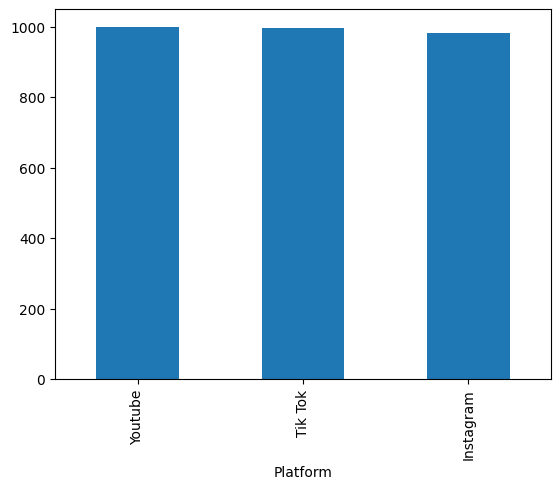

In [ ]:
df_consolidated["Platform"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

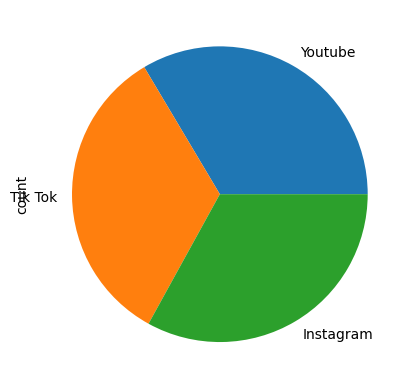

In [ ]:
df_consolidated["Platform"].value_counts().plot(kind="pie")

In [ ]:
df_consolidated["Country"].value_counts(dropna=False)

,count
Country,
NaN,1172
United States,577
India,371
Brazil,222
Indonesia,178
Mexico,102
Russia,46
Spain,36
Argentina,29


In [ ]:
df_consolidated["Country"].value_counts(normalize=True)

,proportion
Country,
United States,0.319491
India,0.205426
Brazil,0.122924
Indonesia,0.098560
Mexico,0.056478
Russia,0.025471
Spain,0.019934
Argentina,0.016058
United Kingdom,0.014950


In [ ]:
print(f"Number of unique countries: {len(df_consolidated['Country'].unique())}")

Number of unique countries: 42


<Axes: xlabel='Country'>

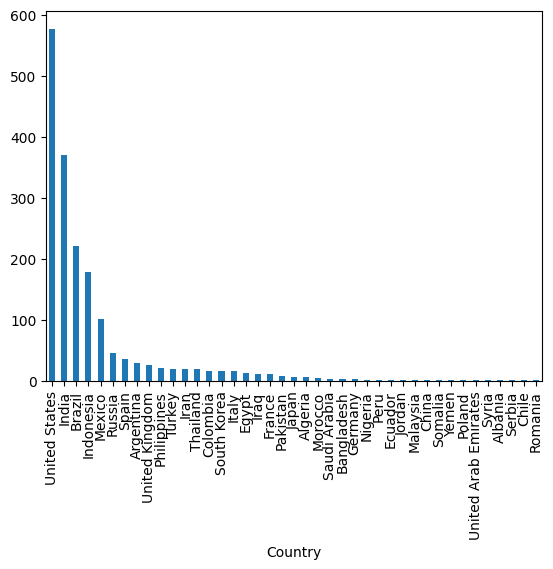

In [ ]:
df_consolidated["Country"].value_counts().plot(kind="bar")

<Axes: title={'center': 'Top 10 countries of influencers'}, xlabel='Country'>

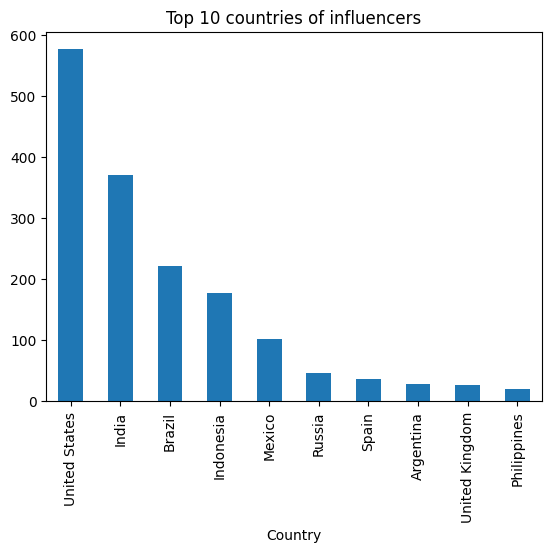

In [ ]:
# Solo top 10
df_consolidated["Country"].value_counts()[:10].plot(kind="bar", title="Top 10 countries of influencers")

In [ ]:
print(f"Number of unique categories: {len(df_consolidated['Category'].unique())}")

Number of unique categories: 48


<Axes: title={'center': 'Top 10 categories of influencers'}, xlabel='Category'>

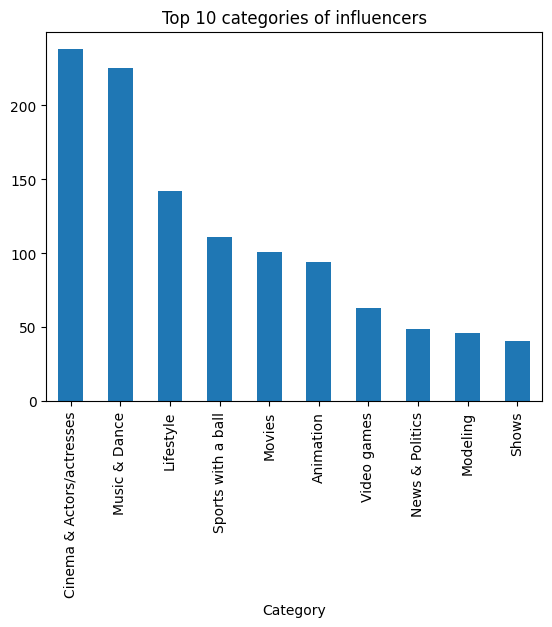

In [ ]:
# Solo top 10
df_consolidated["Category"].value_counts()[:10].plot(kind="bar", title="Top 10 categories of influencers")

<Axes: >

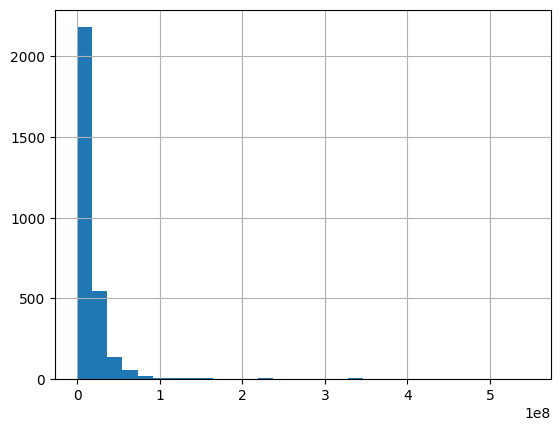

In [ ]:
df_consolidated["Subscribers"].hist(bins=30)

In [ ]:
accounts_in_100m = df_consolidated[df_consolidated["Subscribers"] > 1e8]
print(f"Number of accounts with hundreds of millions of followers: {len(accounts_in_100m)}")
accounts_in_100m

Number of accounts with hundreds of millions of followers: 40


,Date,Platform,Creator,Channel Name,Category,Country,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
1,Sep 2022,Tik Tok,khaby.lame,Khabane lame,NaN,NaN,149200000.0,17300000.0,2300000.0,15200.0,8700.0
10,Sep 2022,Tik Tok,charlidamelio,charli d’amelio,NaN,NaN,146200000.0,15200000.0,959400.0,20800.0,4600.0
996,Sep 2022,Youtube,tseries,T-Series,Music & Dance,India,224400000.0,141500.0,4600.0,125.0,NaN
997,Sep 2022,Youtube,checkgate,Cocomelon - Nursery Rhymes,Education,NaN,142500000.0,12500000.0,64800.0,0.0,NaN
998,Sep 2022,Youtube,PewDiePie,PewDiePie,Animation,United States,111600000.0,1900000.0,130500.0,7400.0,NaN
999,Sep 2022,Youtube,MrBeast6000,MrBeast,Video games,United States,104100000.0,44800000.0,2200000.0,70900.0,NaN
1000,Sep 2022,Youtube,✿ Kids Diana Show,✿ Kids Diana Show,Animation,NaN,100500000.0,6900000.0,34800.0,0.0,NaN
1001,Sep 2022,Youtube,Like Nastya,Like Nastya,Toys,NaN,100400000.0,5300000.0,28100.0,0.0,NaN
1995,Sep 2022,Instagram,Cristiano Ronaldo,cristiano,Sports with a ball,India,477900000.0,6200000.0,5000000.0,NaN,NaN
1996,Sep 2022,Instagram,Kylie 🤍,kyliejenner,Fashion,United States,368100000.0,5500000.0,3500000.0,NaN,NaN


<Axes: >

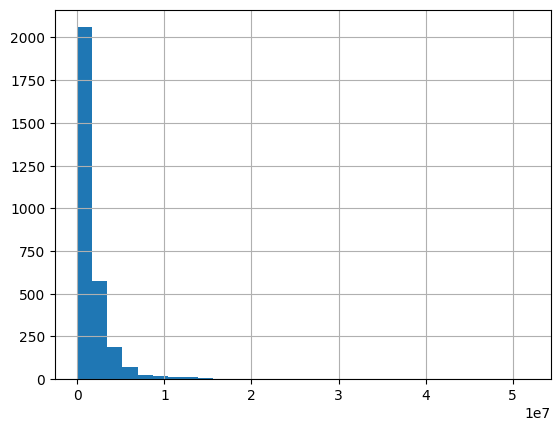

In [ ]:
df_consolidated["Views avg."].hist(bins=30)

<Axes: >

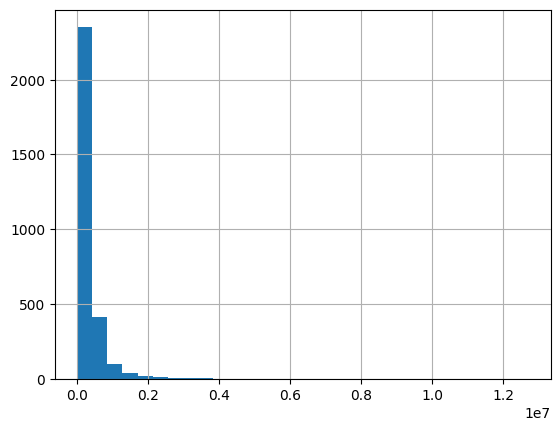

In [ ]:
df_consolidated["Likes avg."].hist(bins=30)

In [ ]:
df_consolidated.select_dtypes(include="number").corr()

,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
Subscribers,1.000000,0.050316,0.234025,0.092568,-0.045345
Views avg.,0.050316,1.000000,0.382637,0.525270,0.147097
Likes avg.,0.234025,0.382637,1.000000,0.459128,0.121725
Comments avg.,0.092568,0.525270,0.459128,1.000000,0.246597
Shares avg.,-0.045345,0.147097,0.121725,0.246597,1.000000


<Axes: >

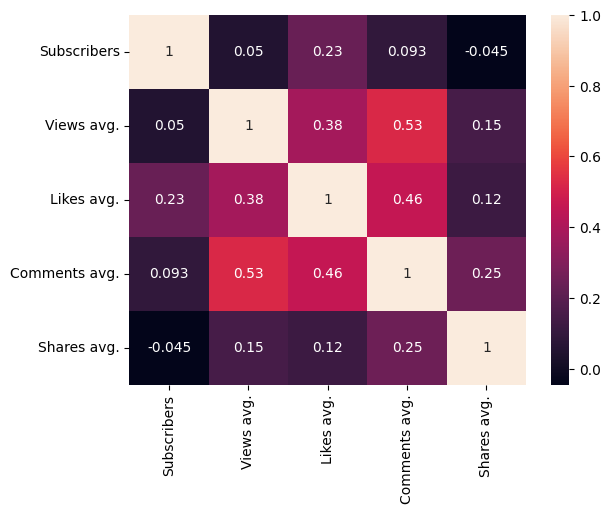

In [ ]:
# Graph correlation with seaborn
import seaborn as sns
sns.heatmap(df_consolidated.select_dtypes(include="number").corr(), annot=True)

<Axes: xlabel='Platform', ylabel='Subscribers'>

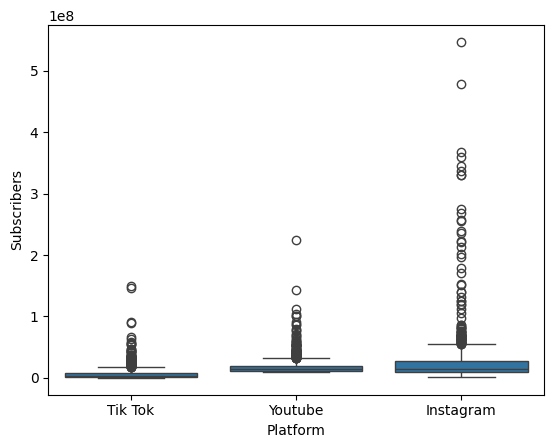

In [ ]:
sns.boxplot(x="Platform", y="Subscribers", data=df_consolidated)

<Axes: xlabel='Platform', ylabel='Views avg.'>

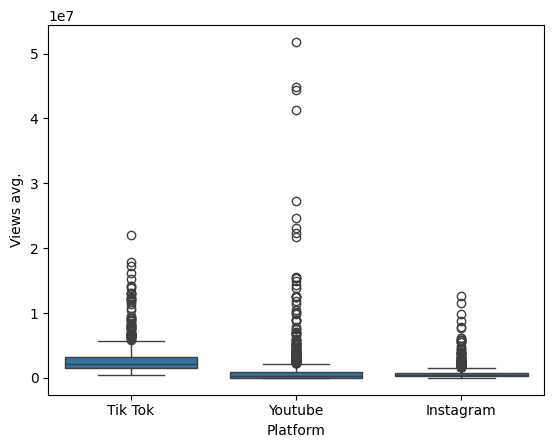

In [ ]:
sns.boxplot(x="Platform", y="Views avg.", data=df_consolidated)

<Axes: xlabel='Platform', ylabel='Comments avg.'>

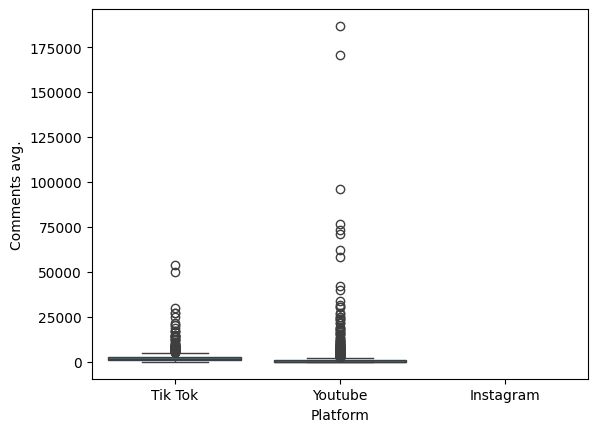

In [ ]:
sns.boxplot(x="Platform", y="Comments avg.", data=df_consolidated)

<Axes: xlabel='Platform', ylabel='Likes avg.'>

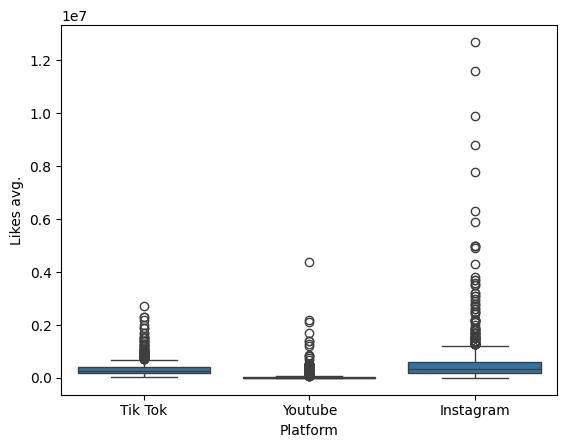

In [ ]:
sns.boxplot(x="Platform", y="Likes avg.", data=df_consolidated)

<Axes: xlabel='Platform', ylabel='Subscribers'>

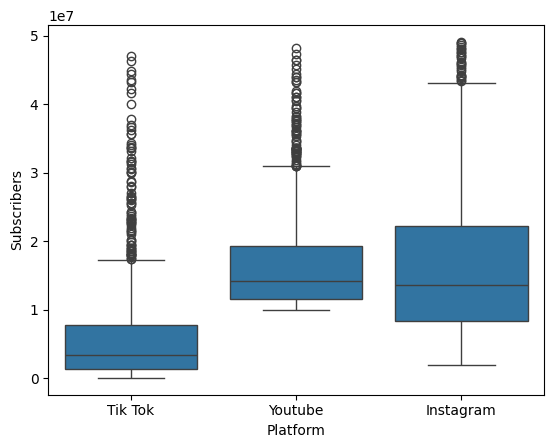

In [ ]:
# Analyzing without subscribers outliers out of .95 percentile
df_consolidated_without_outliers = df_consolidated[df_consolidated["Subscribers"] < df_consolidated["Subscribers"].quantile(.95)]
sns.boxplot(x="Platform", y="Subscribers", data=df_consolidated_without_outliers)

In [ ]:
import matplotlib.pyplot as plt

/tmp/ipykernel_728/2758919424.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'India'),
 Text(1, 0, 'Mexico'),
 Text(2, 0, 'Brazil'),
 Text(3, 0, 'United States'),
 Text(4, 0, 'Russia'),
 Text(5, 0, 'Philippines'),
 Text(6, 0, 'Spain'),
 Text(7, 0, 'Thailand'),
 Text(8, 0, 'Colombia'),
 Text(9, 0, 'France'),
 Text(10, 0, 'Pakistan'),
 Text(11, 0, 'Indonesia'),
 Text(12, 0, 'Ecuador'),
 Text(13, 0, 'United Kingdom'),
 Text(14, 0, 'Turkey'),
 Text(15, 0, 'Saudi Arabia'),
 Text(16, 0, 'Argentina'),
 Text(17, 0, 'Iraq'),
 Text(18, 0, 'Japan'),
 Text(19, 0, 'Algeria'),
 Text(20, 0, 'Bangladesh'),
 Text(21, 0, 'Egypt'),
 Text(22, 0, 'Morocco'),
 Text(23, 0, 'Jordan'),
 Text(24, 0, 'Peru'),
 Text(25, 0, 'Somalia'),
 Text(26, 0, 'Malaysia'),
 Text(27, 0, 'South Korea'),
 Text(28, 0, 'China'),
 Text(29, 0, 'Poland'),
 Text(30, 0, 'Iran'),
 Text(31, 0, 'Yemen'),
 Text(32, 0, 'Italy'),
 Text(33, 0, 'Germany'),
 Text(34, 0, 'Nigeria'),
 Text(35, 0, 'United Arab Emirates'),
 Text(36, 0, 'Syria'),
 Text(37, 0, 'Albania'),
 Text(38, 0, 'Serbia'),
 Text(39, 0, 'Chil

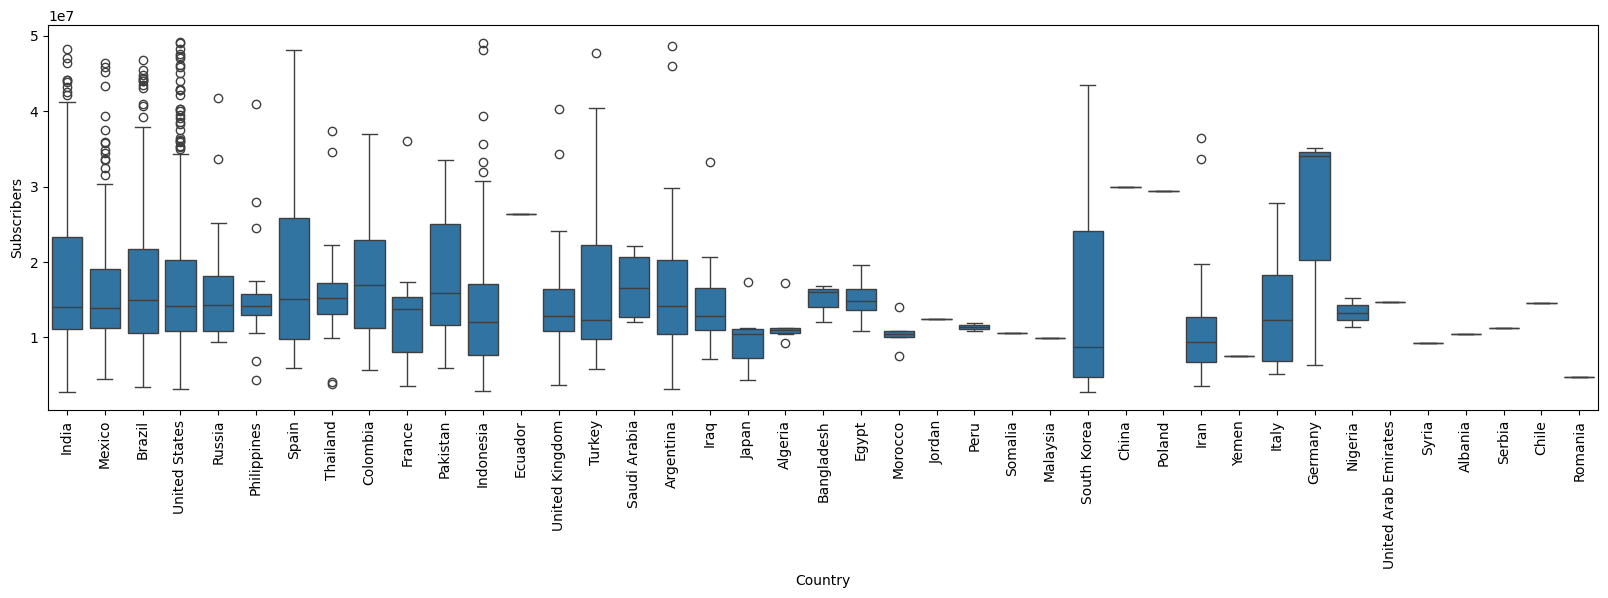

In [ ]:
# Analyzing without subscribers outliers out of .95 percentile
df_consolidated_without_outliers = df_consolidated[df_consolidated["Subscribers"] < df_consolidated["Subscribers"].quantile(.95)]
# create a fig for the boxplot
fig, ax = plt.subplots(figsize=(20, 5))
sns.boxplot(x="Country", y="Subscribers", data=df_consolidated_without_outliers, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
